# **This notebook evaluates the BO algorithm under just settling time and overshoot xtics**

In [ ]:
!pip install control optuna matplotlib numpy scipy plotly kaleido

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from control import tf, feedback, step_response, forced_response, margin
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mass-spring-damper parameters
m = 1.0   # mass (kg)
c = 10.0  # damping coefficient (N*s/m)
k = 20.0  # spring constant (N/m)

# Plant: G(s) = 1 / (ms^2 + cs + k)
G = tf([1], [m, c, k])
print("Plant transfer function:")
print(G)

Plant transfer function:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ---------------
  s^2 + 10 s + 20


In [ ]:
def build_filtered_pid(Kp, Ki, Kd, N):
    """
    Builds the filtered PID transfer function:
    C(s) = Kp + Ki/s + Kd*s/(s/N + 1)
    Combined form: C(s) = [(Kp + Kd*N)s^2 + (Ki + Kp*N)s + Ki*N] / [s(s + N)]
    """
    num = [Kp + Kd*N, Ki + Kp*N, Ki*N]
    den = [1, N, 0]
    return tf(num, den)


def evaluate_pid_full(Kp, Ki, Kd, N, plant, t_sim=5.0, n_points=2000, setpoint=1.0):
    """
    Simulates closed-loop with filtered PID and computes all metrics.

    Returns dict with:
      - Transient: settling_time, overshoot, peak, rise_time
      - Integral: iae, ise
      - Control effort: peak_force, total_effort
      - Frequency: gain_margin_db, phase_margin_deg
      - Stability: is_stable
      - Time series: t, y, u (for plotting)
    """
    try:
        C = build_filtered_pid(Kp, Ki, Kd, N)

        # Closed-loop transfer functions
        L = C * plant                    # Loop gain
        T = feedback(L, 1)               # Closed-loop (reference to output)
        CS = feedback(C, plant)          # Reference to control signal: U/R = C/(1+CL)

        t = np.linspace(0, t_sim, n_points)

        # Step response: output y(t)
        t, y = step_response(T, t)

        # Step response: control signal u(t)
        t, u = step_response(CS, t)

        # Scale by setpoint
        y = y * setpoint
        u = u * setpoint

        # Sanity check for instability
        if (np.any(np.isnan(y)) or np.any(np.isinf(y))
            or np.max(np.abs(y)) > 100):
            return {'is_stable': False}

        error = setpoint - y

        # --- Transient metrics ---
        peak = np.max(y)
        overshoot = max(0.0, (peak - setpoint) / setpoint * 100)

        # Settling time (2% criterion)
        settling_band = 0.02 * setpoint
        outside_band = np.where(np.abs(error) > settling_band)[0]
        settling_time = t[outside_band[-1]] if len(outside_band) > 0 else 0.0

        # Rise time (10% to 90%)
        try:
            t_10 = t[np.where(y >= 0.1 * setpoint)[0][0]]
            t_90 = t[np.where(y >= 0.9 * setpoint)[0][0]]
            rise_time = t_90 - t_10
        except IndexError:
            rise_time = np.nan

        # --- Integral metrics ---
        iae = np.trapz(np.abs(error), t)
        ise = np.trapz(error**2, t)

        # --- Control effort metrics ---
        peak_force = np.max(np.abs(u))
        total_effort = np.trapz(np.abs(u), t)

        # --- Steady-state error ---
        sse = abs(error[-1])

        # --- Frequency-domain metrics ---
        try:
            gm, pm, wcg, wcp = margin(L)
            gain_margin_db = 20 * np.log10(gm) if gm > 0 and np.isfinite(gm) else np.inf
            phase_margin_deg = pm
        except Exception:
            gain_margin_db = np.nan
            phase_margin_deg = np.nan

        return {
            'is_stable': True,
            'settling_time': settling_time,
            'overshoot': overshoot,
            'peak': peak,
            'rise_time': rise_time,
            'iae': iae,
            'ise': ise,
            'peak_force': peak_force,
            'total_effort': total_effort,
            'sse': sse,
            'gain_margin_db': gain_margin_db,
            'phase_margin_deg': phase_margin_deg,
            't': t,
            'y': y,
            'u': u
        }
    except Exception as e:
        return {'is_stable': False, 'error': str(e)}

In [ ]:
# Engineering specifications (constraints)
MAX_OVERSHOOT = 5.0   # %
MAX_SSE = 0.01        # absolute (1% of setpoint=1.0)


def constraints_func(trial):
    """
    Returns the constraint violations for Optuna's TPE sampler.
    Each value: positive means VIOLATED, <= 0 means satisfied.
    """
    return trial.user_attrs.get("constraints", (1.0, 1.0))


def objective(trial):
    """
    Constrained optimization:
      minimize: settling_time
      subject to:
        overshoot <= 5%
        sse <= 0.01
    """
    Kp = trial.suggest_float('Kp', 0.1, 300)
    Ki = trial.suggest_float('Ki', 0.0, 300)
    Kd = trial.suggest_float('Kd', 0.0, 50)
    N  = trial.suggest_float('N', 1, 500)

    result = evaluate_pid_full(Kp, Ki, Kd, N, G)

    if not result.get('is_stable', False):
        # Mark as heavily violated
        trial.set_user_attr("constraints", (1e3, 1e3))
        return 1e6

    # Compute constraint violations (positive = violated)
    c1 = result['overshoot'] - MAX_OVERSHOOT   # overshoot <= 5%
    c2 = result['sse'] - MAX_SSE               # sse <= 0.01

    trial.set_user_attr("constraints", (c1, c2))

    # Store full metrics for later analysis
    trial.set_user_attr("metrics", {
        'settling_time': result['settling_time'],
        'overshoot': result['overshoot'],
        'peak_force': result['peak_force'],
        'total_effort': result['total_effort'],
        'iae': result['iae'],
        'ise': result['ise'],
        'gain_margin_db': result['gain_margin_db'],
        'phase_margin_deg': result['phase_margin_deg'],
    })

    # Objective: settling time only (constraints handled separately)
    return result['settling_time']


# Build the sampler with constraint support
sampler = optuna.samplers.TPESampler(
    seed=42,
    constraints_func=constraints_func,
    n_startup_trials=20
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='constrained_pid_bo'
)

print("Running constrained Bayesian Optimization...")
print(f"Constraints: Overshoot <= {MAX_OVERSHOOT}%, SSE <= {MAX_SSE}")
print("-" * 60)

study.optimize(objective, n_trials=200, show_progress_bar=True)

In [ ]:
def get_best_feasible_trial(study):
    """Returns the feasible trial with the lowest objective value."""
    feasible_trials = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue
        constraints = trial.user_attrs.get("constraints", (1e3, 1e3))
        if all(c <= 0 for c in constraints):
            feasible_trials.append(trial)

    if not feasible_trials:
        return None
    return min(feasible_trials, key=lambda t: t.value)


best = get_best_feasible_trial(study)

if best is None:
    print("⚠️ No feasible solution found! Consider relaxing constraints.")
else:
    print("\n" + "="*60)
    print("BEST FEASIBLE SOLUTION (BO-tuned)")
    print("="*60)
    print(f"\nGains:")
    print(f"  Kp = {best.params['Kp']:.4f}")
    print(f"  Ki = {best.params['Ki']:.4f}")
    print(f"  Kd = {best.params['Kd']:.4f}")
    print(f"  N  = {best.params['N']:.4f}")

    m_dict = best.user_attrs["metrics"]
    print(f"\nPerformance Metrics:")
    print(f"  Settling time:     {m_dict['settling_time']:.4f} s")
    print(f"  Overshoot:         {m_dict['overshoot']:.4f} %")
    print(f"  Peak force:        {m_dict['peak_force']:.4f}")
    print(f"  Total effort:      {m_dict['total_effort']:.4f}")
    print(f"  IAE:               {m_dict['iae']:.4f}")
    print(f"  ISE:               {m_dict['ise']:.4f}")
    print(f"  Gain margin:       {m_dict['gain_margin_db']:.2f} dB")
    print(f"  Phase margin:      {m_dict['phase_margin_deg']:.2f} deg")

    print(f"\nTotal feasible trials: "
          f"{sum(1 for t in study.trials if all(c <= 0 for c in t.user_attrs.get('constraints', (1,1))))}"
          f" / {len(study.trials)}")


BEST FEASIBLE SOLUTION (BO-tuned)

Gains:
  Kp = 215.9822
  Ki = 299.6742
  Kd = 15.0470
  N  = 462.4265

Performance Metrics:
  Settling time:     0.1476 s
  Overshoot:         1.4460 %
  Peak force:        7174.1063
  Total effort:      115.5852
  IAE:               0.0691
  ISE:               0.0300
  Gain margin:       inf dB
  Phase margin:      78.85 deg

Total feasible trials: 172 / 200


/tmp/ipykernel_17040/2159318256.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_17040/2159318256.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_17040/2159318256.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)


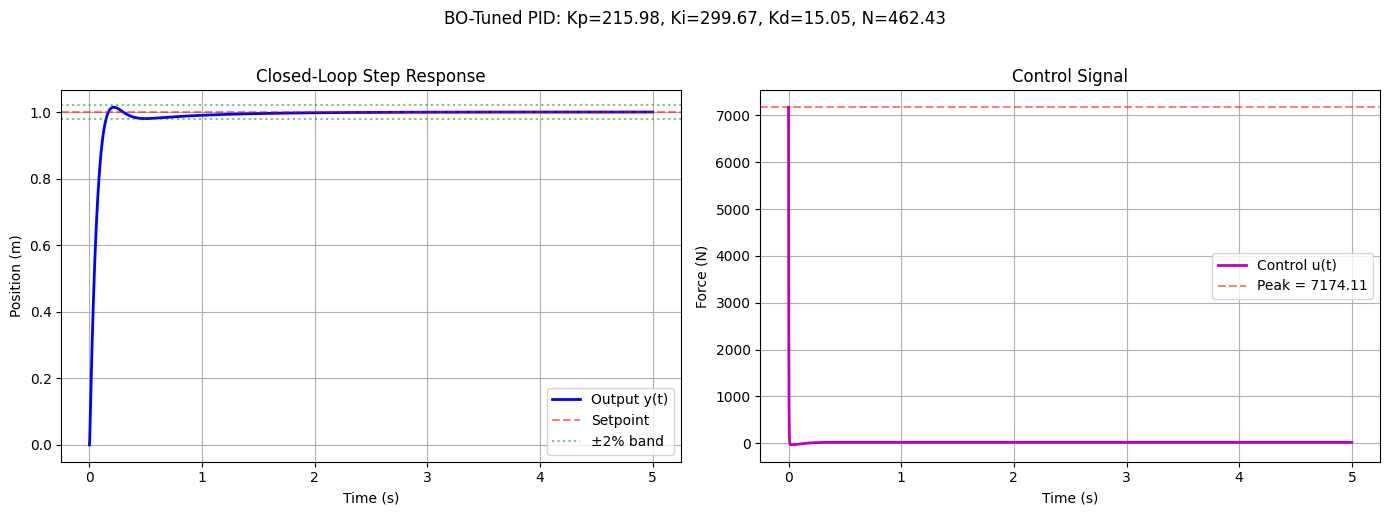

In [ ]:
best_params = best.params
result = evaluate_pid_full(
    best_params['Kp'],
    best_params['Ki'],
    best_params['Kd'],
    best_params['N'],
    G
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Output response
axes[0].plot(result['t'], result['y'], 'b-', linewidth=2, label='Output y(t)')
axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Setpoint')
axes[0].axhline(y=1.02, color='g', linestyle=':', alpha=0.5, label='±2% band')
axes[0].axhline(y=0.98, color='g', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Closed-Loop Step Response')
axes[0].legend()
axes[0].grid(True)

# Control signal
axes[1].plot(result['t'], result['u'], 'm-', linewidth=2, label='Control u(t)')
axes[1].axhline(y=result['peak_force'], color='r', linestyle='--', alpha=0.5,
                label=f'Peak = {result["peak_force"]:.2f}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Force (N)')
axes[1].set_title('Control Signal')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'BO-Tuned PID: Kp={best_params["Kp"]:.2f}, '
             f'Ki={best_params["Ki"]:.2f}, Kd={best_params["Kd"]:.2f}, '
             f'N={best_params["N"]:.2f}', y=1.02)
plt.tight_layout()
plt.show()